## Proximidad de las mediciones a los umbrales de decisión

**Origen.** El asesor cuestionó descartar el bit 4 (Δ = 16 ppb) por estar bajo
el ruido del modelo, señalando que en operación los valores se sitúan cerca de
los cortes normativos y un desplazamiento pequeño basta para cruzarlos.

**Pregunta.** ¿Qué fracción de las mediciones se encuentra a distancia
suficientemente corta de un umbral como para que un ataque de bajo desplazamiento
cambie la banda reportada?

Umbrales NOM-172-SEMARNAT-2023, Tabla 6: **58 / 90 / 135 / 175 ppb**.

Se analizan dos niveles:

1. **Lecturas horarias** — es sobre lo que opera el detector
2. **Máximos diarios** — es lo que determina el reporte diario del índice

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.ingest.rama import load_wide, to_long

UMBRALES = [58, 90, 135, 175]

long = to_long(load_wide('../data/raw/2025O3.xls'), 'O3')
cca = long[(long.station == 'CCA') & long.value.notna()].copy()
cca['fecha'] = cca.timestamp.dt.date

print(f"Lecturas horarias válidas: {len(cca)}")
print(f"Días con dato: {cca.fecha.nunique()}")

Lecturas horarias válidas: 8491
Días con dato: 365


In [2]:
v = cca.value.values

filas = []
for tau in UMBRALES:
    fila = {'umbral': tau}
    for bit in [3, 4, 5, 6]:
        d = 2 ** bit
        # lecturas que un flip de +d llevaría por encima del umbral
        cruzan = ((v <= tau) & (v > tau - d)).sum()
        fila[f'bit {bit} (±{d})'] = f"{cruzan} ({cruzan/len(v)*100:.2f}%)"
    filas.append(fila)

pd.DataFrame(filas)

,umbral,bit 3 (±8),bit 4 (±16),bit 5 (±32),bit 6 (±64)
0,58,427 (5.03%),887 (10.45%),2251 (26.51%),6578 (77.47%)
1,90,225 (2.65%),545 (6.42%),1289 (15.18%),3540 (41.69%)
2,135,22 (0.26%),74 (0.87%),294 (3.46%),1287 (15.16%)
3,175,0 (0.00%),0 (0.00%),5 (0.06%),172 (2.03%)


In [3]:
maximos = cca.groupby('fecha').value.max()

print(f"Días analizados: {len(maximos)}")
print(f"Máximo diario — media {maximos.mean():.1f}, mediana {maximos.median():.0f}")
print()

for tau in UMBRALES:
    for bit in [4, 5]:
        d = 2 ** bit
        n = ((maximos <= tau) & (maximos > tau - d)).sum()
        if n:
            print(f"τ={tau:>3}  bit {bit} (±{d:>2}):  {n:>3} días "
                  f"({n/len(maximos)*100:5.1f}%) cruzarían la banda")

Días analizados: 365
Máximo diario — media 90.4, mediana 92

τ= 58  bit 4 (±16):   19 días (  5.2%) cruzarían la banda
τ= 58  bit 5 (±32):   37 días ( 10.1%) cruzarían la banda
τ= 90  bit 4 (±16):   82 días ( 22.5%) cruzarían la banda
τ= 90  bit 5 (±32):  127 días ( 34.8%) cruzarían la banda
τ=135  bit 4 (±16):   36 días (  9.9%) cruzarían la banda
τ=135  bit 5 (±32):  110 días ( 30.1%) cruzarían la banda
τ=175  bit 5 (±32):    4 días (  1.1%) cruzarían la banda


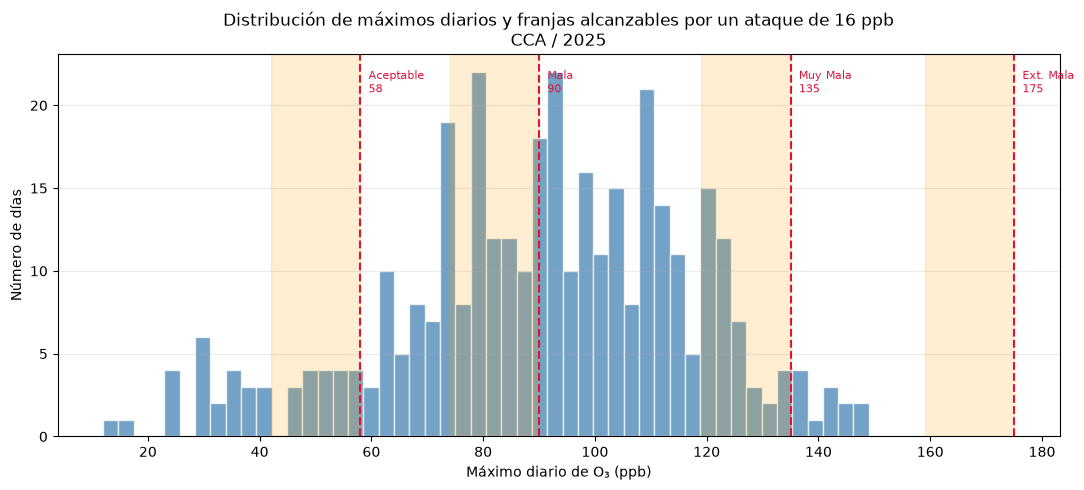

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(maximos, bins=50, color='steelblue', alpha=0.75, edgecolor='white')

for tau, etq in zip(UMBRALES, ['Aceptable', 'Mala', 'Muy Mala', 'Ext. Mala']):
    ax.axvline(tau, ls='--', c='crimson', lw=1.5)
    ax.text(tau + 1.5, ax.get_ylim()[1]*0.9, f'{etq}\n{tau}',
            fontsize=8, color='crimson')
    # franja alcanzable por un flip del bit 4
    ax.axvspan(tau - 16, tau, alpha=0.18, color='orange')

ax.set_xlabel('Máximo diario de O₃ (ppb)')
ax.set_ylabel('Número de días')
ax.set_title('Distribución de máximos diarios y franjas alcanzables por un ataque de 16 ppb\nCCA / 2025')
ax.grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig('../docs/img/proximidad_umbrales.png', dpi=150)
plt.show()

## Potenciales conclusiones

Teniendo Máximo diario — media 90.4, mediana 92. Ademas como nota gracias al Doc, una contingencia ambiental fase 1 Mayor a 150 puntos (equivalente a más de 154 partes por billón - ppb en promedio horario). para la Fase II (Emergencia): Se activa al rebasar los 200 puntos en cualquier contaminante. Esto debe mantenerse (para fase 1 o 2) al menos pior una hora. 

Podemos destacar que para la media estandar de 90.4 ataques de bit 3 apenas 225 (2.65%) se verian afectados o si es que esa afimracion esta mal, todas las mediciiones que esten cerca de esa media estarian vulnerables a ataque muy pequeños de bit 3 que podrian (si se apaga el bit) bajar la banda. 

Ahora incluso para la media de 90.4 ataques de bit 5 apenas y haria que cruzara el umbral (que de hecho mi intuicion me dice que este bit para esos casos si o si estaria prendido, por lo que haria casi siempre un ataque a la baja, seria necesario ver como se contituyen estos datos para ver si hay un patron claro que las medidas de media siempre tienen algun bit encendido), se necesitarian ataques mas agresivos pero mas detectables para activar una contingencia que arrebase los 150ppb 


In [7]:
for bit in [3, 4, 5, 6]:
    encendido = ((cca.value.astype(int) >> bit) & 1).astype(bool)
    print(f"bit {bit}: encendido en {encendido.mean()*100:5.1f}% de las lecturas")
    
    # solo en la franja que cruza τ=90
    franja = (cca.value > 90 - 2**bit) & (cca.value <= 90)
    print(f"        en la franja de τ=90: {encendido[franja].mean()*100:5.1f}%")

TypeError: unsupported operand type(s) for >>: 'Series' and 'int'